# Data Loading

In [ ]:
import kagglehub

path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-customer-churn-analysis-and-prediction' dataset.
Path to dataset files: /kaggle/input/ecommerce-customer-churn-analysis-and-prediction


In [ ]:
import os
print(os.listdir(path))

['E Commerce Dataset.xlsx']


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading data
file_path = os.path.join(path, 'E Commerce Dataset.xlsx')

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['Data Dict', 'E Comm']


In [ ]:
df = pd.read_excel(file_path, sheet_name='E Comm')
print(df['Churn'].value_counts())
df.head()

Churn
0    4682
1     948
Name: count, dtype: int64


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


#  Data Tidying & Cleaning

In [ ]:
df.shape

(5630, 20)

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [ ]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [ ]:
num_cols = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,5366.0,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.0,15.0,18.0,26.0
CouponUsed,5374.0,1.751023,1.894621,0.0,1.0,1.0,2.0,16.0
OrderCount,5372.0,3.008004,2.939680,1.0,1.0,2.0,3.0,16.0
DaySinceLastOrder,5323.0,4.543491,3.654433,0.0,2.0,3.0,7.0,46.0


In [ ]:
# Check missing values
missing_cols = df.isnull().sum()
missing_cols[missing_cols > 0]

,0
Tenure,264
WarehouseToHome,251
HourSpendOnApp,255
OrderAmountHikeFromlastYear,265
CouponUsed,256
OrderCount,258
DaySinceLastOrder,307


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [ ]:
# Final check
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

Series([], dtype: int64)


In [ ]:
# Chek duplication
df.duplicated().sum()

np.int64(0)

In [ ]:
df['CityTier']  = df['CityTier'].astype('object')
df['Complain']  = df['Complain'].astype('object')
df['Churn'] = df['Churn'].astype(int)

In [ ]:
# Compute outlier counts and percentages
results = []
for col in num_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (series < lower) | (series > upper)
    count = outlier_mask.sum()
    pct = (count / series.count()) * 100
    results.append({
        'variable': col,
        'outlier_count': count,
        'outlier_pct': round(pct, 2)
    })

outlier_df = pd.DataFrame(results).sort_values(by='outlier_pct', ascending=False)
print(outlier_df.to_string(index=False))

                   variable  outlier_count  outlier_pct
                      Churn            948        16.84
                 OrderCount            703        12.49
                 CouponUsed            629        11.17
             CashbackAmount            438         7.78
   NumberOfDeviceRegistered            397         7.05
          DaySinceLastOrder             62         1.10
OrderAmountHikeFromlastYear             33         0.59
             HourSpendOnApp              6         0.11
            NumberOfAddress              4         0.07
                     Tenure              4         0.07
            WarehouseToHome              2         0.04
                   CityTier              0         0.00
                 CustomerID              0         0.00
                   Complain              0         0.00
          SatisfactionScore              0         0.00


In [ ]:
# Handle Outliers
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn' in num_cols:
    num_cols.remove('Churn')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

In [ ]:
# Check inconsistent values
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
----------------------------------------
CityTier
[3 1 2]
----------------------------------------
PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
----------------------------------------
Gender
['Female' 'Male']
----------------------------------------
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
----------------------------------------
MaritalStatus
['Single' 'Divorced' 'Married']
----------------------------------------
Complain
[1 0]
----------------------------------------


In [ ]:
# Handle inconsistent values
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone'
})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery',
    'CC': 'Credit Card'
})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
    'Mobile Phone': 'Mobile'
})

In [ ]:
# Check again inconsistent values
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

PreferredLoginDevice
['Mobile Phone' 'Computer']
----------------------------------------
CityTier
[3 1 2]
----------------------------------------
PreferredPaymentMode
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
----------------------------------------
Gender
['Female' 'Male']
----------------------------------------
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Others' 'Fashion' 'Grocery']
----------------------------------------
MaritalStatus
['Single' 'Divorced' 'Married']
----------------------------------------
Complain
[1 0]
----------------------------------------


In [ ]:
# Categorical features
cat_features = [
    'PreferredPaymentMode',
    'PreferredLoginDevice',
    'Gender',
    'MaritalStatus',
    'PreferedOrderCat',
    'Complain'
]

print("\n========== CATEGORICAL FEATURES ==========\n")

for col in cat_features:
    print(f"\n===== {col} =====")

    df[col] = df[col].fillna('Unknown')
    result = df.groupby(col)['Churn'].mean().sort_values(ascending=False)

    print(result)
    print("-" * 40)


========== CATEGORICAL FEATURES ==========


===== PreferredPaymentMode =====
PreferredPaymentMode
Cash on Delivery    0.249027
E wallet            0.228013
UPI                 0.173913
Debit Card          0.153846
Credit Card         0.142052
Name: Churn, dtype: float64
----------------------------------------

===== PreferredLoginDevice =====
PreferredLoginDevice
Computer        0.198286
Mobile Phone    0.156156
Name: Churn, dtype: float64
----------------------------------------

===== Gender =====
Gender
Male      0.177305
Female    0.154942
Name: Churn, dtype: float64
----------------------------------------

===== MaritalStatus =====
MaritalStatus
Single      0.267261
Divorced    0.146226
Married     0.115204
Name: Churn, dtype: float64
----------------------------------------

===== PreferedOrderCat =====
PreferedOrderCat
Mobile                0.274038
Fashion               0.154964
Laptop & Accessory    0.102439
Others                0.075758
Grocery               0.048780
Nam

/tmp/ipykernel_6143/3488875041.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna('Unknown')


In [ ]:
# Numerical features
num_features = [
    'OrderCount',
    'CashbackAmount',
    'Tenure',
    'DaySinceLastOrder'
]

print("\n========== NUMERICAL FEATURES (BINNED) ==========\n")

for col in num_features:
    print(f"\n===== {col} =====")

    binned = pd.cut(df[col], bins=4)

    result = df.pivot_table(values='Churn', index=binned, aggfunc='mean')
    result = result.sort_values(by='Churn', ascending=False)

    print(result)
    print("-" * 40)


========== NUMERICAL FEATURES (BINNED) ==========


===== OrderCount =====
                  Churn
OrderCount             
(2.25, 3.5]    0.183288
(0.995, 2.25]  0.174517
(4.75, 6.0]    0.144956
(3.5, 4.75]    0.137255
----------------------------------------

===== CashbackAmount =====
                       Churn
CashbackAmount              
(69.634, 120.459]   0.424779
(120.459, 171.081]  0.200631
(171.081, 221.704]  0.132089
(221.704, 272.326]  0.083857
----------------------------------------

===== Tenure =====
                   Churn
Tenure                  
(-0.033, 8.25]  0.276765
(8.25, 16.5]    0.096884
(16.5, 24.75]   0.059850
(24.75, 33.0]   0.000000
----------------------------------------

===== DaySinceLastOrder =====
                      Churn
DaySinceLastOrder          
(-0.0145, 3.625]   0.211644
(3.625, 7.25]      0.136998
(7.25, 10.875]     0.104628
(10.875, 14.5]     0.061688
----------------------------------------


/tmp/ipykernel_6143/2259630919.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  result = df.pivot_table(values='Churn', index=binned, aggfunc='mean')
/tmp/ipykernel_6143/2259630919.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  result = df.pivot_table(values='Churn', index=binned, aggfunc='mean')
/tmp/ipykernel_6143/2259630919.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  result = df.pivot_table(values='Churn', index=binned, aggfunc='mean')
/tmp/ipykernel_6143/2259630919.py:16: FutureWa

# Feature Extraction

In [ ]:
# Orders per tenure
df['OrdersPerTenure'] = df['OrderCount'] / (df['Tenure'] + 1)

This feature measures how active a customer is over their relationship duration with the company. It helps capture customer engagement over time.

In [ ]:
# Is Active Customer or not
df['IsActive'] = (df['DaySinceLastOrder'] < 10).astype(int)

This feature converts recency into a binary feature indicating whether a customer is currently active or inactive.

In [ ]:
# Recency level
import pandas as pd

df['RecencyLevel'] = pd.cut(
    df['DaySinceLastOrder'],
    bins=[0, 10, 30, 60, 1000],
    labels=[0, 1, 2, 3]
)

This feature groups customers based on how recently they interacted with the company, making the pattern easier for the model to learn.

In [ ]:
# Average order value
df['AvgOrderValue'] = df['CashbackAmount'] / (df['OrderCount'] + 1)

This feature shows the cashback received per order, reflecting customer engagement and spending efficiency.

In [ ]:
# Engagement Score
df['EngagementScore'] = df['OrderCount'] * df['CouponUsed']

This feature captures how actively customers use coupons while purchasing, reflecting engagement behavior.

# Feature Selection

In [ ]:
# Mutual Information
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# Encoding
X_sel = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True).fillna(0)
y_sel = df['Churn']

mi_scores = mutual_info_classif(X_sel, y_sel, random_state=42)

mi_features = pd.Series(mi_scores, index=X_sel.columns)
mi_features = mi_features.sort_values(ascending=False)

print("Top Features (Mutual Information):")
print(mi_features.head(10))

Top Features (Mutual Information):
AvgOrderValue                          0.160005
CashbackAmount                         0.138696
Tenure                                 0.123728
OrdersPerTenure                        0.109684
Complain                               0.029709
PreferedOrderCat_Mobile                0.024508
DaySinceLastOrder                      0.021717
CustomerID                             0.021217
MaritalStatus_Married                  0.015850
PreferedOrderCat_Laptop & Accessory    0.011746
dtype: float64


In [ ]:
# SelectKBest
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_sel)

selector = SelectKBest(score_func=chi2, k=10)
selector.fit(X_scaled, y_sel)

selected_features = X_sel.columns[selector.get_support()]

print(selected_features)

Index(['Tenure', 'Complain', 'DaySinceLastOrder', 'OrdersPerTenure',
       'CityTier_3', 'PreferedOrderCat_Grocery',
       'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
       'MaritalStatus_Married', 'MaritalStatus_Single'],
      dtype='object')


In [ ]:
# Comparison
import pandas as pd

# SelectKBest results
kbest_features = selected_features

# Mutual Information results
mi_top = mi_features.head(10).index

common_features = list(set(kbest_features) & set(mi_top))
if len(common_features) == 0:
    common_features = list(mi_top)

print("Selected Features:", common_features)

Selected Features: ['OrdersPerTenure', 'DaySinceLastOrder', 'Tenure', 'PreferedOrderCat_Laptop & Accessory', 'MaritalStatus_Married', 'PreferedOrderCat_Mobile', 'Complain']


In [ ]:
# Comparison
import pandas as pd

# SelectKBest results
kbest_features = selected_features

kbest_df = pd.DataFrame({
   "Feature": kbest_features,
   "Selected_By": "SelectKBest (Chi2)"
})

# Mutual Information results
mi_top = mi_features.head(10).index

mi_df = pd.DataFrame({
   "Feature": mi_top,
   "Selected_By": "Mutual Information"
 })

common_features = list(set(kbest_features) & set(mi_top))
if len(common_features) == 0:
    common_features = list(mi_top)

print("Selected Features:", common_features)

comparison_df = pd.concat([kbest_df, mi_df], ignore_index=True)
comparison_df["In_Both"] = comparison_df["Feature"].isin(kbest_features) & comparison_df["Feature"].isin(mi_top)

print(comparison_df)

Selected Features: ['OrdersPerTenure', 'DaySinceLastOrder', 'Tenure', 'PreferedOrderCat_Laptop & Accessory', 'MaritalStatus_Married', 'PreferedOrderCat_Mobile', 'Complain']
                                Feature         Selected_By  In_Both
0                                Tenure  SelectKBest (Chi2)     True
1                              Complain  SelectKBest (Chi2)     True
2                     DaySinceLastOrder  SelectKBest (Chi2)     True
3                       OrdersPerTenure  SelectKBest (Chi2)     True
4                            CityTier_3  SelectKBest (Chi2)    False
5              PreferedOrderCat_Grocery  SelectKBest (Chi2)    False
6   PreferedOrderCat_Laptop & Accessory  SelectKBest (Chi2)     True
7               PreferedOrderCat_Mobile  SelectKBest (Chi2)     True
8                 MaritalStatus_Married  SelectKBest (Chi2)     True
9                  MaritalStatus_Single  SelectKBest (Chi2)    False
10                        AvgOrderValue  Mutual Information    False

# Train-Test Split

In [ ]:
df_model = df.copy()

In [ ]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

X = X.reindex(columns=common_features, fill_value=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imbalance Handling & Modeling

In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Check Imbalance
print("Train distribution:")
print(y_train.value_counts())

print("\nTrain ratio:")
print(y_train.value_counts(normalize=True))

Train distribution:
Churn
0    3746
1     758
Name: count, dtype: int64

Train ratio:
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64


In [ ]:
# Model before imbalance handling
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\n===== XGBoost (Before Imbalance Handling) =====\n")
print(classification_report(y_test, y_pred_xgb))


===== XGBoost (Before Imbalance Handling) =====

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       936
           1       0.72      0.59      0.65       190

    accuracy                           0.89      1126
   macro avg       0.82      0.77      0.80      1126
weighted avg       0.89      0.89      0.89      1126



In [ ]:
# Handle imbalance
neg = sum(y_train == 0)
pos = sum(y_train == 1)

scale_pos_weight = neg / pos

print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 4.941952506596306


In [ ]:
# Model after imbalance handling
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model_bal = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
xgb_model_bal.fit(X_train, y_train)

y_pred_proba = xgb_model_bal.predict_proba(X_test)[:, 1]

# Threshold tuning
threshold = 0.5
y_pred_xgb_bal = (y_pred_proba > threshold).astype(int)

# Evaluation
print("\n===== XGBoost (After Imbalance Handling) =====\n")
print(classification_report(y_test, y_pred_xgb_bal))


===== XGBoost (After Imbalance Handling) =====

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       936
           1       0.53      0.85      0.65       190

    accuracy                           0.85      1126
   macro avg       0.75      0.85      0.78      1126
weighted avg       0.89      0.85      0.86      1126



# Visualization

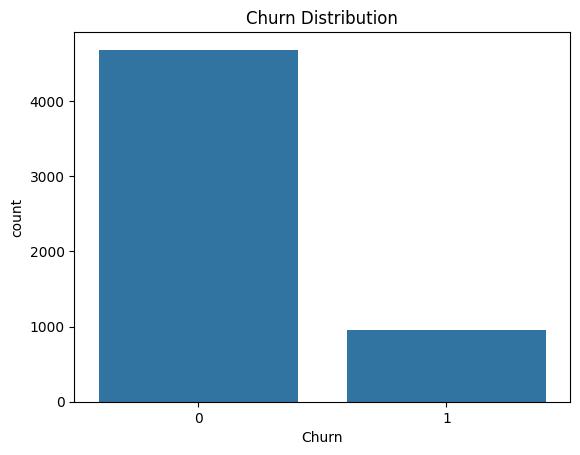

In [ ]:
# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

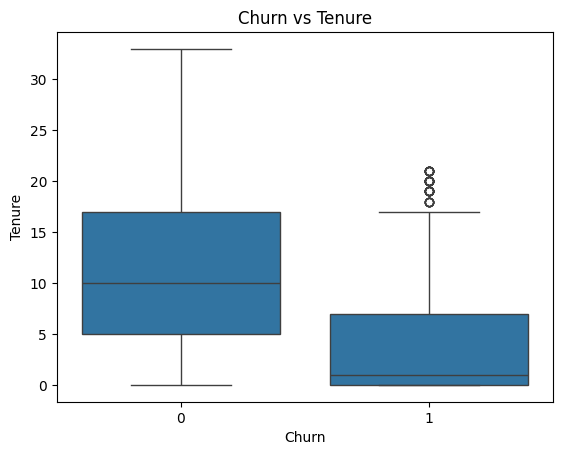

In [ ]:
# Churn vs Tenure
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title("Churn vs Tenure")
plt.show()

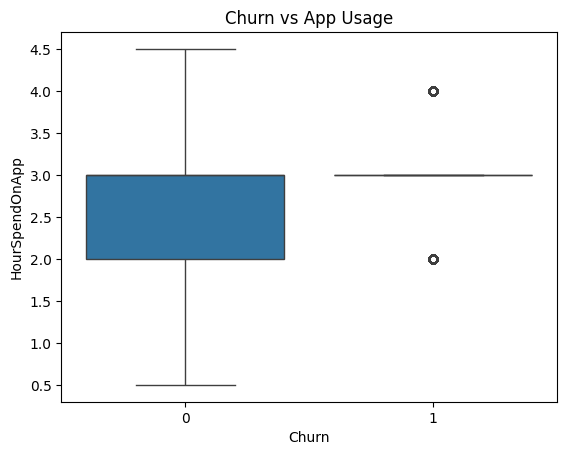

In [ ]:
# Churn vs App Usage
sns.boxplot(x='Churn', y='HourSpendOnApp', data=df)
plt.title("Churn vs App Usage")
plt.show()

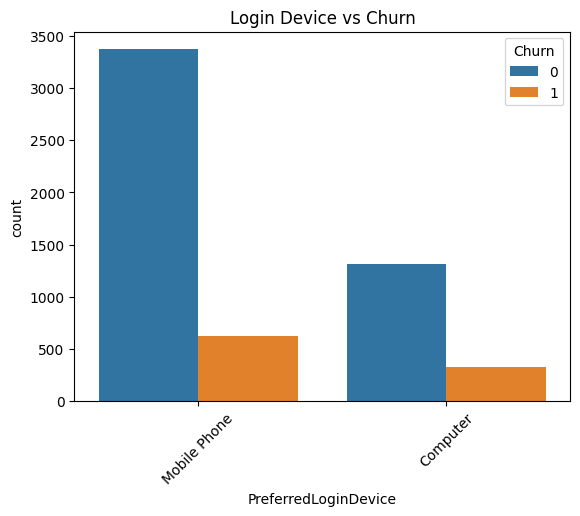

In [ ]:
# Churn vs Preferred Login Device
sns.countplot(x='PreferredLoginDevice', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Login Device vs Churn")
plt.show()

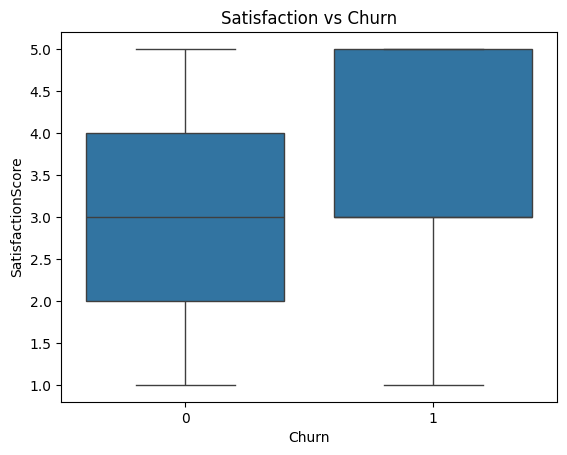

In [ ]:
# Churn vs Satisfaction Score
sns.boxplot(x='Churn', y='SatisfactionScore', data=df)
plt.title("Satisfaction vs Churn")
plt.show()

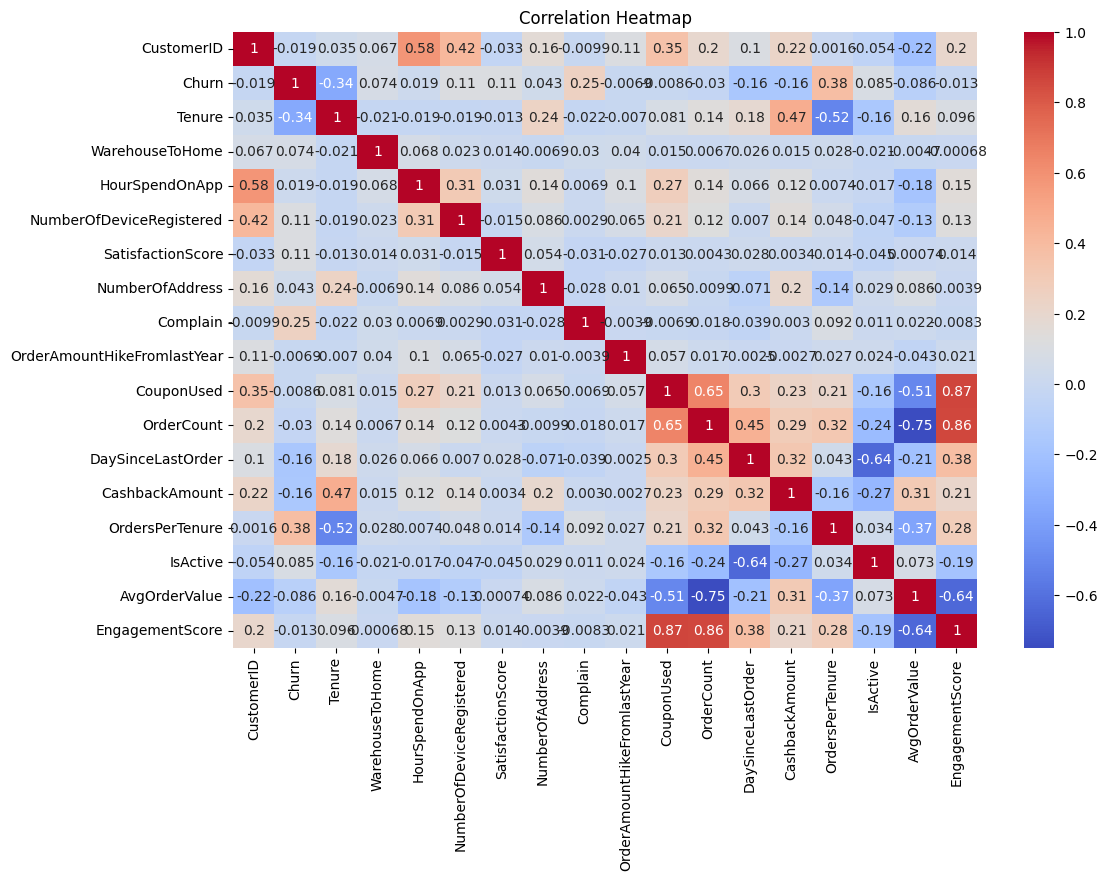

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

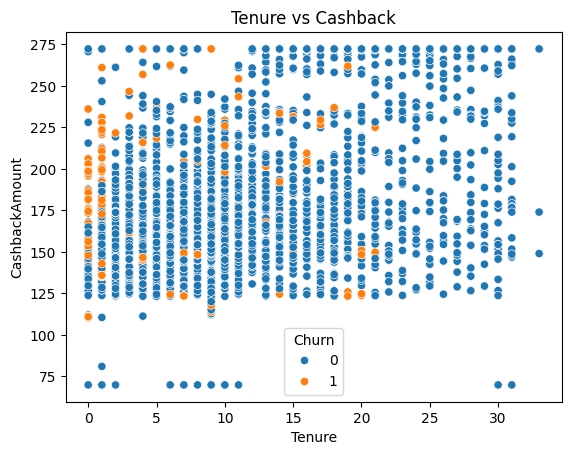

In [ ]:
# Tenure vs Cashback (Scatter Plot)
sns.scatterplot(x='Tenure', y='CashbackAmount', hue='Churn', data=df)
plt.title("Tenure vs Cashback")
plt.show()

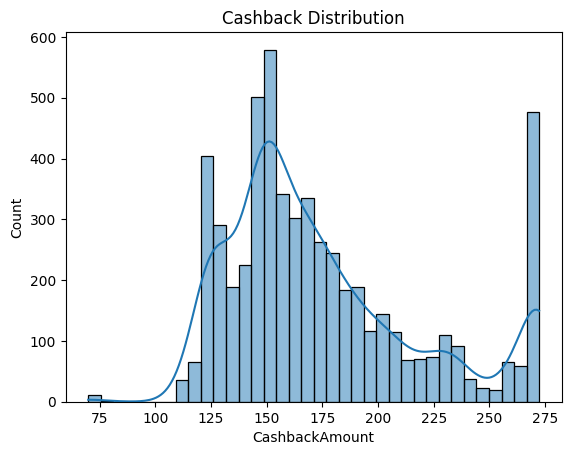

In [ ]:
# Cashback Distribution
sns.histplot(df['CashbackAmount'], kde=True)
plt.title("Cashback Distribution")
plt.show()

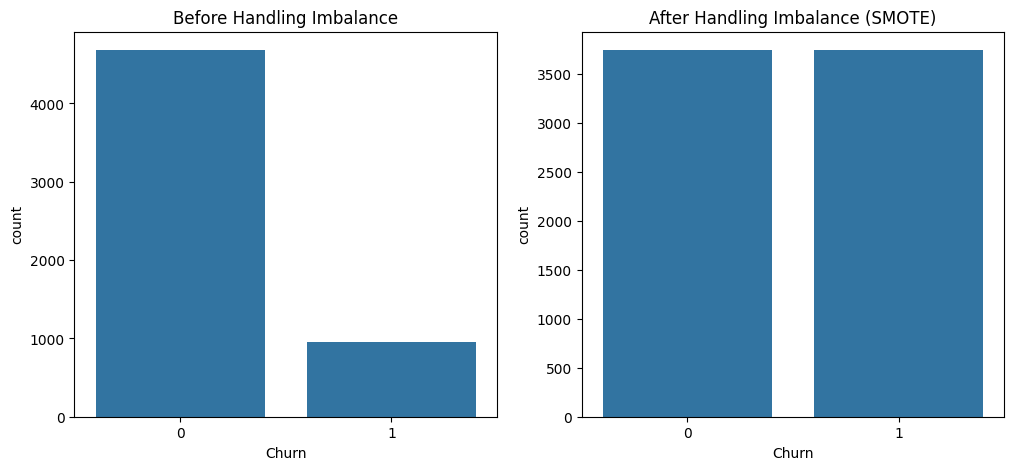

In [ ]:
# Churn Distribution Before vs After Imbalance Handling
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before handling
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title("Before Handling Imbalance")

# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

df_resampled = pd.DataFrame(X_resampled, columns=X_train.columns)
df_resampled['Churn'] = y_resampled

# After handling
sns.countplot(x='Churn', data=df_resampled, ax=axes[1])
axes[1].set_title("After Handling Imbalance (SMOTE)")

plt.show()

# Testing

In [ ]:
import numpy as np

print("Enter customer details:\n")

tenure = float(input("Tenure: "))
city_tier = float(input("CityTier (1/2/3): "))
hour_spend = float(input("Hour Spend On App: "))
devices = float(input("Number Of Device Registered: "))
complain = float(input("Complain (0 or 1): "))
order_count = float(input("Order Count: "))
days_last_order = float(input("Day Since Last Order: "))

user_data = np.array([[
    tenure,
    city_tier,
    hour_spend,
    devices,
    complain,
    order_count,
    days_last_order
]])


proba = xgb_model_bal.predict_proba(user_data)[0][1]

threshold = 0.4
prediction = 1 if proba > threshold else 0

print("\n===== RESULT =====")
print("Churn Probability:", round(proba, 3))

if prediction == 1:
    print("HIGH risk of churn")
else:
    print("LOW risk of churn")

Enter customer details:

Tenure: 4
CityTier (1/2/3): 3
Hour Spend On App: 2
Number Of Device Registered: 3
Complain (0 or 1): 1
Order Count: 3
Day Since Last Order: 3

===== RESULT =====
Churn Probability: 0.299
LOW risk of churn
